# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
# TODO
print("Data size: ",df.shape)
print("Data column: ", df.columns)
print("Data types:\n",df.dtypes)

Data size:  (541909, 8)
Data column:  Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')
Data types:
 InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


## A.2. Missing values & Duplicate data

In [3]:
# TODO
print(df.isnull().sum())
print("-------------------")
print(df.duplicated().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
-------------------
5268


## A.3. Invalid values

In [4]:
# TODO
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [5]:
# TODO
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

df['Sales'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [6]:
# TODO
df.mean(numeric_only=True)

Quantity         10.542037
UnitPrice         3.907625
CustomerID    15294.423453
Sales            20.121871
dtype: float64

In [7]:
df.median(numeric_only=True)

Quantity          3.00
UnitPrice         2.08
CustomerID    15159.00
Sales             9.90
dtype: float64

In [8]:
df.mode()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1,2011-10-31 14:41:00,1.25,17841.0,United Kingdom,15.0


## Group 2 — Dispersion

In [9]:
# TODO
df.std(numeric_only=True)

Quantity       155.524124
UnitPrice       35.915681
CustomerID    1713.141560
Sales          270.356743
dtype: float64

In [10]:
range = df.max(numeric_only=True) - df.min(numeric_only=True)

range

Quantity       80994.000
UnitPrice      13541.329
CustomerID      5941.000
Sales         168469.599
dtype: float64

In [11]:
iqr = df.quantile(0.75, numeric_only=True)-df.quantile(0.25, numeric_only=True)

iqr

Quantity         9.00
UnitPrice        2.88
CustomerID    2826.00
Sales           13.95
dtype: float64

## Group 3 — Location and Shape

In [12]:
# TODO
df.quantile([0.25, 0.5, 0.75], numeric_only=True)

,Quantity,UnitPrice,CustomerID,Sales
0.25,1.0,1.25,13969.0,3.75
0.50,3.0,2.08,15159.0,9.90
0.75,10.0,4.13,16795.0,17.70


In [13]:
df.skew(numeric_only=True)

Quantity      471.727716
UnitPrice     206.087555
CustomerID      0.025729
Sales         506.706012
dtype: float64

In [14]:
df.kurtosis(numeric_only=True)

Quantity      236462.342826
UnitPrice      62483.142715
CustomerID        -1.180822
Sales         297651.661046
dtype: float64

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

Quốc gia có doanh thu cao nhất: United Kingdom
Doanh thu: 9025222.08
Chiếm: 84.61 % tổng doanh thu


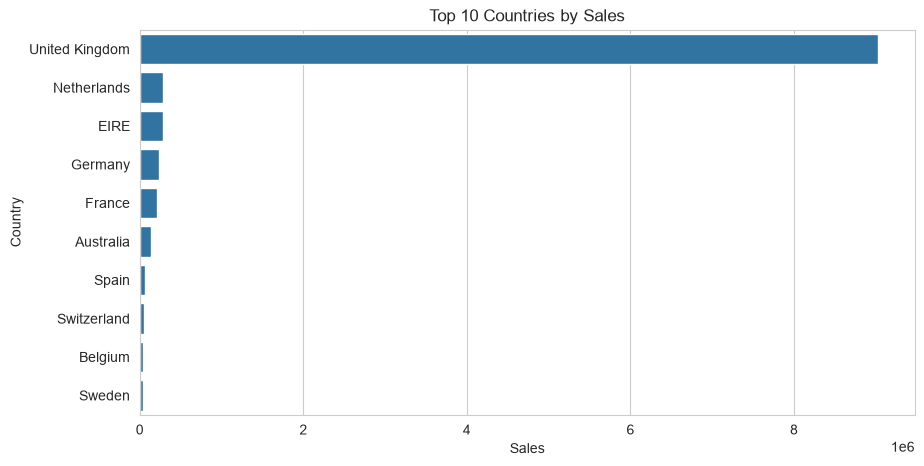

In [15]:
# TODO
country_sales = (df.groupby('Country')['Sales'].sum().sort_values(ascending=False))

total_sales = country_sales.sum()

top_country = country_sales.idxmax()
top_sales = country_sales.max()
top_percent = top_sales / total_sales * 100

print("Quốc gia có doanh thu cao nhất:", top_country)
print("Doanh thu:", round(top_sales, 2))
print("Chiếm:", round(top_percent, 2), "% tổng doanh thu")

top10_country = country_sales.head(10).reset_index()

plt.figure(figsize=(10, 5))

sns.barplot(data=top10_country, x='Sales', y='Country')

plt.title('Top 10 Countries by Sales')
plt.xlabel('Sales')
plt.ylabel('Country')

plt.show()

## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

Sản phẩm có doanh thu cao nhất:
Description
DOTCOM POSTAGE    206248.77
Name: Sales, dtype: float64

Top 10 sản phẩm:
Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Sales, dtype: float64


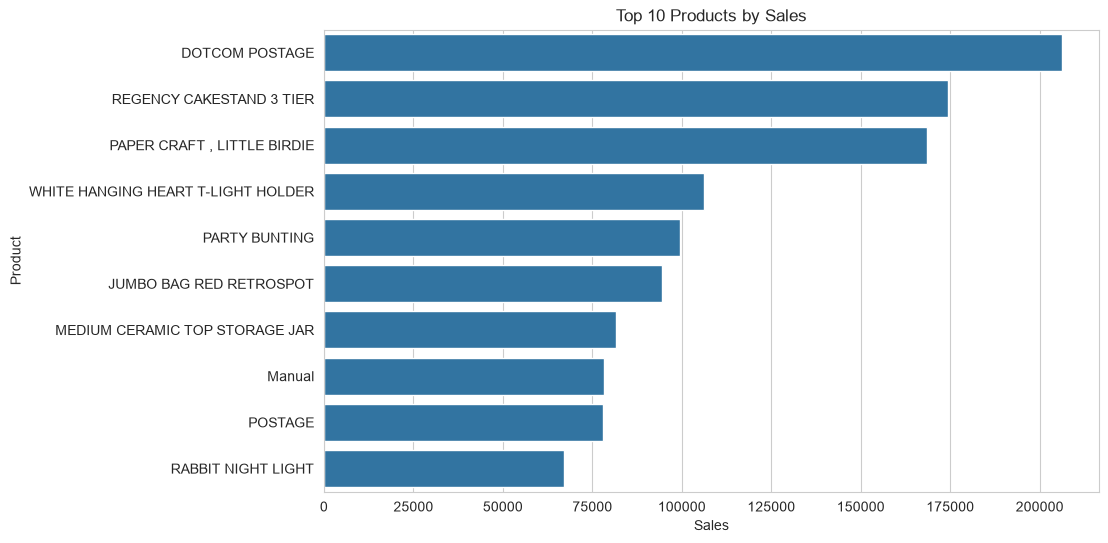

In [16]:
# TODO
product_sales = (df.groupby('Description')['Sales'].sum().sort_values(ascending=False))

print("Sản phẩm có doanh thu cao nhất:")
print(product_sales.head(1))

print("\nTop 10 sản phẩm:")
print(product_sales.head(10))

top10_product = product_sales.head(10).reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(data=top10_product, x='Sales', y='Description')

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')

plt.show()


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

   YearMonth        Sales
0    2010-12   823746.140
1    2011-01   691364.560
2    2011-02   523631.890
3    2011-03   717639.360
4    2011-04   537808.621
5    2011-05   770536.020
6    2011-06   761739.900
7    2011-07   719221.191
8    2011-08   759138.380
9    2011-09  1058590.172
10   2011-10  1154979.300
11   2011-11  1509496.330
12   2011-12   638792.680


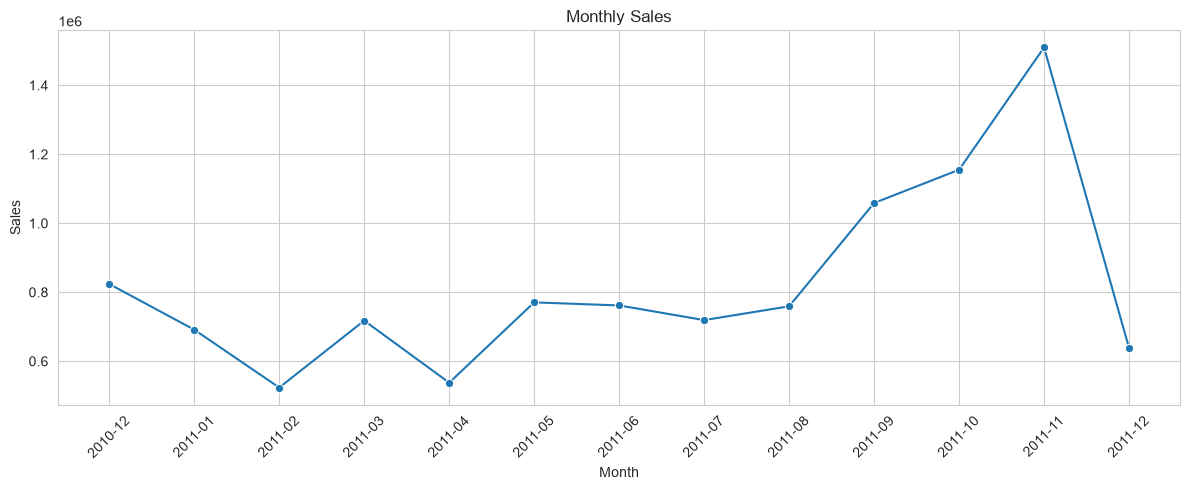

In [17]:
# TODO
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

monthly_sales = (df.groupby('YearMonth')['Sales'].sum().reset_index())

print(monthly_sales)

plt.figure(figsize=(12, 5))

sns.lineplot(data=monthly_sales, x='YearMonth', y='Sales', marker='o')

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

Average Order Value theo quốc gia:
Country
Singapore               3039.898571
Netherlands             3036.663191
Australia               2430.198421
Japan                   1969.282632
Lebanon                 1693.880000
Hong Kong               1426.527273
Brazil                  1143.600000
Sweden                  1066.064722
Switzerland             1057.220370
Denmark                 1053.074444
Israel                  1016.907500
Norway                  1004.595556
RSA                     1002.310000
EIRE                     984.215139
Greece                   952.104000
Cyprus                   849.398750
Channel Islands          786.555385
USA                      716.078000
Spain                    684.190111
United Arab Emirates     634.093333
Iceland                  615.714286
Canada                   611.063333
Austria                  599.922353
Portugal                 581.846552
Finland                  549.904390
Malta                    545.118000
France               

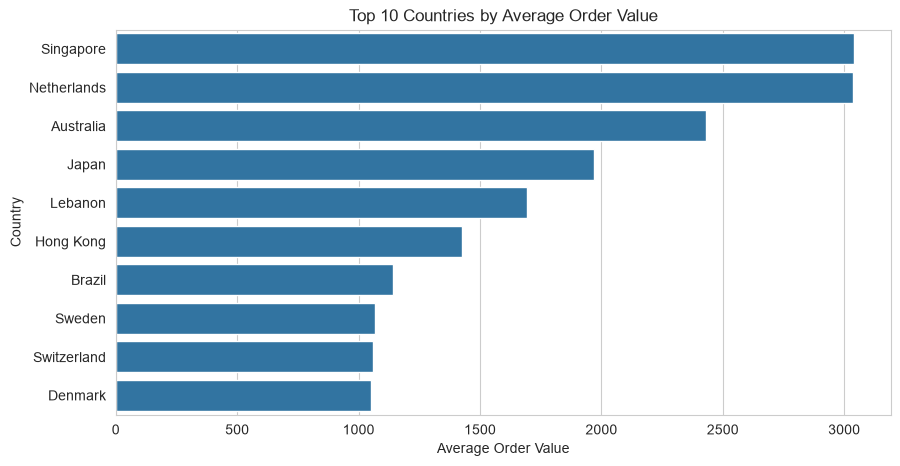

In [18]:
# TODO
order_value = (df.groupby(['Country', 'InvoiceNo'])['Sales'].sum().reset_index())

country_aov = (order_value.groupby('Country')['Sales'].mean().sort_values(ascending=False))

print("Average Order Value theo quốc gia:")
print(country_aov)

print("\nQuốc gia có AOV cao nhất:", country_aov.idxmax())
print("AOV:", round(country_aov.max(), 2))

top10_aov = country_aov.head(10).reset_index()

plt.figure(figsize=(10, 5))

sns.barplot(data=top10_aov, x='Sales', y='Country')

plt.title('Top 10 Countries by Average Order Value')
plt.xlabel('Average Order Value')
plt.ylabel('Country')

plt.show()


## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

Tỷ lệ giao dịch trả hàng/hủy theo quốc gia (%):
Country
Czech Republic          60.000000
Malta                   50.000000
Saudi Arabia            50.000000
Japan                   32.142857
Italy                   30.909091
Singapore               30.000000
USA                     28.571429
Switzerland             27.027027
Hong Kong               26.666667
Bahrain                 25.000000
Germany                 24.212272
Sweden                  21.739130
Channel Islands         21.212121
Poland                  20.833333
United Kingdom          20.039159
European Community      20.000000
Cyprus                  20.000000
EIRE                    20.000000
Portugal                18.309859
Belgium                 17.647059
Australia               17.391304
Greece                  16.666667
France                  14.967462
Finland                 14.583333
Denmark                 14.285714
Spain                   14.285714
Israel                  11.111111
Austria                 10

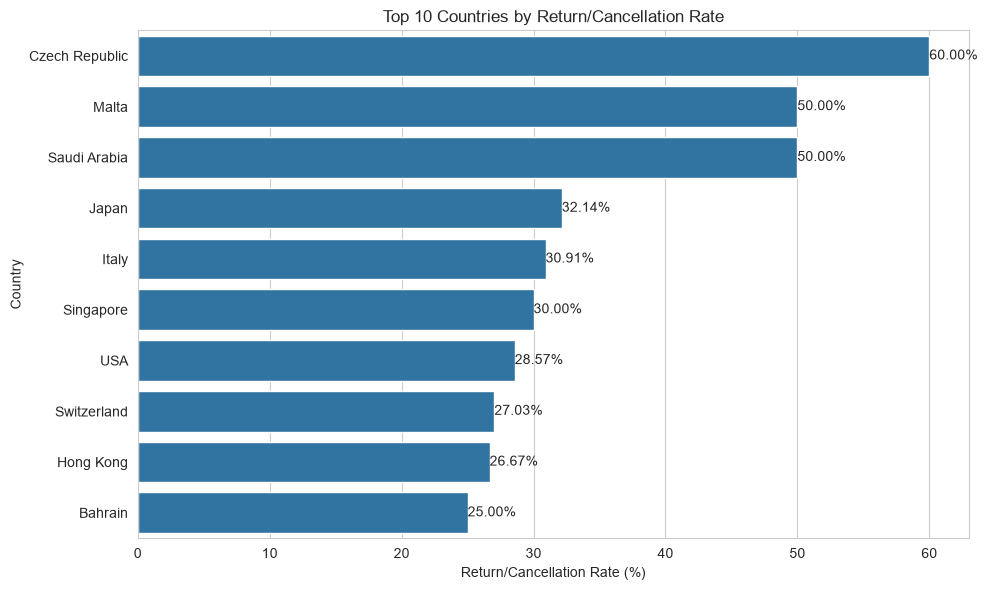

In [19]:
# TODO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv"

df_raw = pd.read_csv(url)
df_raw['Return'] = df_raw['Quantity'] < 0
order_return = (df_raw.groupby(['Country', 'InvoiceNo'])['Return'].max().reset_index())

return_rate = (order_return.groupby('Country')['Return'].mean().mul(100).sort_values(ascending=False))

print("Tỷ lệ giao dịch trả hàng/hủy theo quốc gia (%):")
print(return_rate)

top10_return = return_rate.head(10).reset_index()
top10_return.columns = ['Country', 'ReturnRate']

print("\nTop 10 quốc gia:")
print(top10_return)

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=top10_return, x='ReturnRate', y='Country')

plt.title('Top 10 Countries by Return/Cancellation Rate')
plt.xlabel('Return/Cancellation Rate (%)')
plt.ylabel('Country')

for container in ax.containers:ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*(Viết insight của bạn vào đây...)*
## Phần A – Data Profiling:
* Dữ liệu ban đầu có một số giá trị thiếu, dữ liệu trùng và các giao dịch có `Quantity` hoặc `UnitPrice` không hợp lệ; sau khi làm sạch và tạo cột `Sales = Quantity × UnitPrice`, dữ liệu phù hợp hơn cho phân tích doanh thu.
## Phần B – Descriptive Statistics:
* Các biến `Quantity`, `UnitPrice` và `Sales` có độ phân tán lớn và phân phối lệch phải, cho thấy phần lớn giao dịch có giá trị tương đối thấp nhưng tồn tại một số giao dịch có giá trị rất cao.
## Phần C – Quốc gia và sản phẩm: 
* Doanh thu không phân bố đồng đều giữa các quốc gia và sản phẩm mà tập trung mạnh vào một số thị trường và một số sản phẩm bán chạy, cho thấy đây là những nhóm đóng góp chính vào tổng doanh thu.

* Thời gian và giá trị đơn hàng:Doanh thu thay đổi đáng kể giữa các tháng, cho thấy có dấu hiệu mùa vụ; đồng thời Average Order Value cũng khác nhau giữa các quốc gia, phản ánh sự khác biệt về hành vi mua sắm.

* Trả hàng/hủy:Tỷ lệ giao dịch có dấu hiệu trả hàng hoặc hủy khác nhau giữa các quốc gia, vì vậy doanh nghiệp nên theo dõi các thị trường có tỷ lệ cao để tìm nguyên nhân và giảm tổn thất doanh thu.
